# Pipeline y modelado

Aquí montamos el flujo completo: datos → modelos → evaluación. La lógica repetida está en `src/` para no saturar el notebook.

Comparamos CNN baseline, ResNet50 y EfficientNetB0. Métrica principal: **F1 macro** (por el desbalance visto en el EDA).


## 0. Imports y dispositivo


In [1]:
import sys
sys.path.insert(0, "..")  # raíz del proyecto, para importar src

import torch
import torch.nn as nn

from src.data import (asegurar_dataset, cargar_y_limpiar, dividir_estratificado,
                      construir_transforms, crear_dataloaders, NOMBRES_CLASES)
from src.models import (CNNBaseline, construir_resnet50, descongelar_resnet,
                        construir_efficientnet_b0, descongelar_efficientnet)
from src.training import calcular_pesos, evaluar, entrenar
from src.visualization import graficar_historial, matriz_confusion

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", dispositivo)

Dispositivo: cuda


## 1. Datos

Cargamos el HDF5, aplicamos la limpieza de duplicados del EDA y hacemos split 70/15/15 estratificado para que cada clase esté representada en los tres conjuntos.


In [2]:
RUTA = "../data/raw/Galaxy10_DECals.h5"
asegurar_dataset(RUTA)  # descarga ~2,5 GB desde Zenodo la primera vez

imagenes, clases = cargar_y_limpiar(RUTA)
print(f"Imágenes tras eliminar duplicados: {len(imagenes)}")

idx_train, idx_val, idx_test = dividir_estratificado(clases)
print(f"Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}")

Imágenes tras eliminar duplicados: 17615
Train: 12329  Val: 2643  Test: 2643


## 2. Transforms y DataLoaders

- Redimensionamos a 224 (tamaño estándar de ImageNet).
- Normalizamos con media/std de ImageNet.
- Augmentation solo en train: rotaciones y flips (la orientación no define la morfología).
- Pesos de clase en `CrossEntropyLoss` para penalizar más los errores en clases raras.


In [3]:
transform_train, transform_eval = construir_transforms(tam=224)

dl_train, dl_val, dl_test = crear_dataloaders(
    imagenes, clases, idx_train, idx_val, idx_test,
    transform_train, transform_eval, batch=32)

# Pesos inversos a la frecuencia de clase (desbalance del EDA)
pesos = calcular_pesos(clases, idx_train, dispositivo)
criterio = nn.CrossEntropyLoss(weight=pesos)

In [4]:
imgs, labs = next(iter(dl_train))
print("Lote de imágenes:", tuple(imgs.shape), imgs.dtype)
print("Lote de etiquetas:", tuple(labs.shape), labs.dtype)
print("Rango de valores:", round(imgs.min().item(), 2), "a", round(imgs.max().item(), 2))

Lote de imágenes: (32, 3, 224, 224) torch.float32
Lote de etiquetas: (32,) torch.int64
Rango de valores: -2.12 a 2.64


## 3. CNN baseline

Red convolucional entrenada desde cero. Nos sirve de referencia para ver cuánto mejora el transfer learning.


In [5]:
modelo_base = CNNBaseline(num_clases=10).to(dispositivo)
n_params = sum(p.numel() for p in modelo_base.parameters())
print(f"Parámetros entrenables: {n_params:,}")

hist_base = entrenar(modelo_base, dl_train, dl_val, criterio, dispositivo,
                     epocas=8, lr=1e-3, etiqueta="baseline")

Parámetros entrenables: 12,939,722


Época  1 | loss 1.938 | F1 val 0.420 | acc val 0.442


Época  2 | loss 1.547 | F1 val 0.490 | acc val 0.513


Época  3 | loss 1.406 | F1 val 0.472 | acc val 0.491


Época  4 | loss 1.331 | F1 val 0.550 | acc val 0.588


Época  5 | loss 1.250 | F1 val 0.574 | acc val 0.595


Época  6 | loss 1.205 | F1 val 0.618 | acc val 0.638


Época  7 | loss 1.157 | F1 val 0.631 | acc val 0.664


Época  8 | loss 1.118 | F1 val 0.620 | acc val 0.653


La baseline llega a ~0,63 F1 en validación. No es mal resultado para una red pequeña sin preentrenamiento, pero tiene muchos parámetros en la capa densa.

## 4. ResNet50 — feature extraction

Cargamos pesos de ImageNet, congelamos todo el backbone y entrenamos solo la capa final de 10 salidas.


In [6]:
modelo_resnet = construir_resnet50(num_clases=10, dispositivo=dispositivo)
hist_resnet = entrenar(modelo_resnet, dl_train, dl_val, criterio, dispositivo,
                       epocas=12, lr=1e-3, etiqueta="resnet50_fase1")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\al3xc/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

 15%|█▌        | 15.1M/97.8M [00:00<00:00, 149MB/s]

 44%|████▍     | 43.0M/97.8M [00:00<00:00, 214MB/s]

 65%|██████▍   | 63.5M/97.8M [00:00<00:00, 214MB/s]

...

Época  8 | loss 1.374 | F1 val 0.491 | acc val 0.504


Época  9 | loss 1.356 | F1 val 0.485 | acc val 0.507


Época 10 | loss 1.343 | F1 val 0.488 | acc val 0.511


Época 11 | loss 1.327 | F1 val 0.492 | acc val 0.516


Época 12 | loss 1.336 | F1 val 0.509 | acc val 0.538


Con el backbone congelado ResNet se queda en ~0,50 F1, **por debajo de la baseline**. Las fotos naturales de ImageNet no se parecen mucho a imágenes astronómicas tenues.


### 4.1 Fine-tuning (layer4)

Recargamos el mejor modelo de la fase anterior, descongelamos `layer4` y bajamos el LR a 1e-4.


In [7]:
# Mejor checkpoint de la fase 1
modelo_resnet.load_state_dict(torch.load("../models/resnet50_fase1.pt"))
descongelar_resnet(modelo_resnet)  # layer4 pasa a entrenarse

hist_resnet_ft = entrenar(modelo_resnet, dl_train, dl_val, criterio, dispositivo,
                          epocas=20, lr=1e-4, etiqueta="resnet50_finetuning")

Época  1 | loss 1.095 | F1 val 0.625 | acc val 0.651


Época  2 | loss 0.909 | F1 val 0.673 | acc val 0.699


Época  3 | loss 0.822 | F1 val 0.670 | acc val 0.698


Época  4 | loss 0.780 | F1 val 0.687 | acc val 0.714


Época  5 | loss 0.733 | F1 val 0.682 | acc val 0.709


...

Época 16 | loss 0.525 | F1 val 0.748 | acc val 0.767


Época 17 | loss 0.477 | F1 val 0.752 | acc val 0.773


Época 18 | loss 0.462 | F1 val 0.740 | acc val 0.764


Época 19 | loss 0.449 | F1 val 0.757 | acc val 0.779


Época 20 | loss 0.445 | F1 val 0.761 | acc val 0.778


### 4.2 Fine-tuning extendido (layer3 + layer4)

Partimos del mejor checkpoint anterior, descongelamos también `layer3` y usamos LR=1e-5 para no romper lo ya aprendido.


In [8]:
# Segunda ronda de fine-tuning desde el mejor modelo anterior
modelo_resnet.load_state_dict(torch.load("../models/resnet50_finetuning.pt"))

# Descongelamos layer3 y layer4 (LR muy bajo en la celda de entrenar)
for capa in (modelo_resnet.layer3, modelo_resnet.layer4):
    for p in capa.parameters():
        p.requires_grad = True

hist_resnet_ft2 = entrenar(modelo_resnet, dl_train, dl_val, criterio, dispositivo,
                           epocas=15, lr=1e-5, etiqueta="resnet50_finetuning_v2")

Época  1 | loss 0.411 | F1 val 0.770 | acc val 0.790


Época  2 | loss 0.382 | F1 val 0.766 | acc val 0.788


Época  3 | loss 0.361 | F1 val 0.768 | acc val 0.788


Época  4 | loss 0.350 | F1 val 0.776 | acc val 0.795


Época  5 | loss 0.346 | F1 val 0.777 | acc val 0.795


...

Época  9 | loss 0.307 | F1 val 0.782 | acc val 0.800


Época 10 | loss 0.299 | F1 val 0.781 | acc val 0.800


Época 11 | loss 0.301 | F1 val 0.782 | acc val 0.802


Época 12 | loss 0.287 | F1 val 0.778 | acc val 0.796


Época 13 | loss 0.281 | F1 val 0.778 | acc val 0.796
Early stopping en época 13 (mejor F1: 0.783)


Aquí está el salto grande: de ~0,50 (congelado) a ~0,78 F1 en val. En **test** el mejor modelo llega a 0,784 F1 y 0,801 accuracy.

## 5. EfficientNetB0

Repetimos el mismo esquema de dos fases con otro backbone para comparar arquitecturas.


In [9]:
modelo_eff = construir_efficientnet_b0(num_clases=10, dispositivo=dispositivo)
hist_eff = entrenar(modelo_eff, dl_train, dl_val, criterio, dispositivo,
                    epocas=12, lr=1e-3, etiqueta="efficientnet_fase1")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\al3xc/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


  0%|          | 0.00/20.5M [00:00<?, ?B/s]

 79%|███████▉  | 16.1M/20.5M [00:00<00:00, 155MB/s]

100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]

Época  1 | loss 1.980 | F1 val 0.263 | acc val 0.275


...

Época  8 | loss 1.722 | F1 val 0.337 | acc val 0.377


Época  9 | loss 1.736 | F1 val 0.360 | acc val 0.396


Época 10 | loss 1.724 | F1 val 0.360 | acc val 0.393


Época 11 | loss 1.713 | F1 val 0.350 | acc val 0.396


Época 12 | loss 1.721 | F1 val 0.351 | acc val 0.399


### 5.1 Fine-tuning EfficientNet

Descongelamos los dos últimos bloques de `features`.


In [10]:
modelo_eff.load_state_dict(torch.load("../models/efficientnet_fase1.pt"))
descongelar_efficientnet(modelo_eff, n_bloques=2)

hist_eff_ft = entrenar(modelo_eff, dl_train, dl_val, criterio, dispositivo,
                       epocas=20, lr=1e-4, etiqueta="efficientnet_finetuning")

Época  1 | loss 1.578 | F1 val 0.445 | acc val 0.479


Época  2 | loss 1.474 | F1 val 0.471 | acc val 0.498


Época  3 | loss 1.412 | F1 val 0.492 | acc val 0.517


Época  4 | loss 1.369 | F1 val 0.498 | acc val 0.521


Época  5 | loss 1.349 | F1 val 0.499 | acc val 0.530


...

Época 16 | loss 1.150 | F1 val 0.561 | acc val 0.585


Época 17 | loss 1.139 | F1 val 0.551 | acc val 0.581


Época 18 | loss 1.127 | F1 val 0.556 | acc val 0.585


Época 19 | loss 1.129 | F1 val 0.570 | acc val 0.593


Época 20 | loss 1.112 | F1 val 0.571 | acc val 0.598


## 6. Comparativa y evaluación en test

Juntamos curvas de entrenamiento, tabla de F1 por configuración y matriz de confusión del modelo que mejor validó.


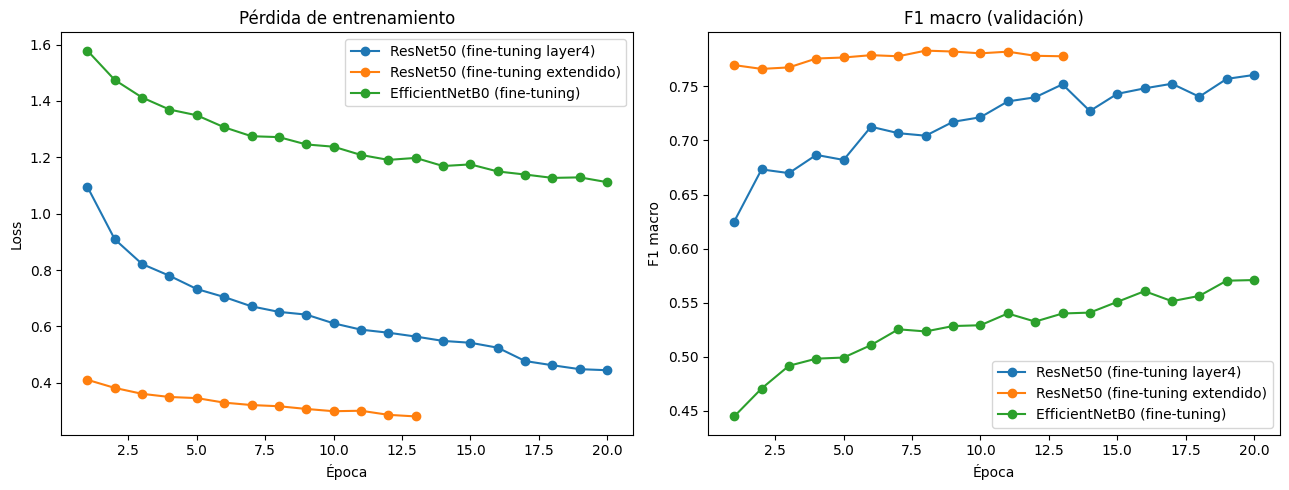

In [11]:
graficar_historial(
    {"ResNet50 (fine-tuning layer4)": hist_resnet_ft,
     "ResNet50 (fine-tuning extendido)": hist_resnet_ft2,
     "EfficientNetB0 (fine-tuning)": hist_eff_ft},
    ruta="../reports/figures/curvas_entrenamiento.png")

In [12]:
import pandas as pd

def mejor(historial):
    return max(r["f1_val"] for r in historial)

comparativa = pd.DataFrame({
    "Modelo": ["CNN base",
               "ResNet50 (feature extraction)",
               "ResNet50 (fine-tuning · layer4)",
               "ResNet50 (fine-tuning extendido · layer3+layer4)",
               "EfficientNetB0 (feature extraction)",
               "EfficientNetB0 (fine-tuning)"],
    "Mejor F1 val": [mejor(hist_base),
                     mejor(hist_resnet),
                     mejor(hist_resnet_ft),
                     mejor(hist_resnet_ft2),
                     mejor(hist_eff),
                     mejor(hist_eff_ft)],
}).round(3).sort_values("Mejor F1 val", ascending=False).reset_index(drop=True)
comparativa

,Modelo,Mejor F1 val
0,ResNet50 (fine-tuning extendido · layer3+layer4),0.783
1,ResNet50 (fine-tuning · layer4),0.761
2,CNN base,0.631
3,EfficientNetB0 (fine-tuning),0.571
4,ResNet50 (feature extraction),0.509
5,EfficientNetB0 (feature extraction),0.360


In [13]:
from sklearn.metrics import classification_report

# Seleccionar el modelo ganador según la comparativa anterior.
# Por defecto, ResNet50 fine-tuning; cambiar a modelo_eff / efficientnet_finetuning.pt si gana.
mejor_modelo = modelo_resnet
mejor_pt = "../models/resnet50_finetuning_v2.pt"


mejor_modelo.load_state_dict(torch.load(mejor_pt))
f1_test, acc_test, y_true, y_pred = evaluar(mejor_modelo, dl_test, dispositivo)
print(f"F1 macro test: {f1_test:.3f}")
print(f"Accuracy test: {acc_test:.3f}\n")
print(classification_report(y_true, y_pred, target_names=NOMBRES_CLASES, digits=3))

F1 macro test: 0.784
Accuracy test: 0.801

                         precision    recall  f1-score   support

              Disturbed      0.536     0.468     0.500       158
                Merging      0.823     0.873     0.847       276
           Round Smooth      0.858     0.922     0.889       395
In-between Round Smooth      0.882     0.888     0.885       303
    Cigar Shaped Smooth      0.672     0.820     0.739        50
          Barred Spiral      0.800     0.745     0.772       306
  Unbarred Tight Spiral      0.670     0.714     0.691       273
  Unbarred Loose Spiral      0.720     0.653     0.685       389
  Edge-on without Bulge      0.885     0.939     0.911       213
     Edge-on with Bulge      0.944     0.900     0.921       280

               accuracy                          0.801      2643
              macro avg      0.779     0.792     0.784      2643
           weighted avg      0.799     0.801     0.799      2643



### Resultados en test

Evaluamos una sola vez el conjunto de test con los pesos de `resnet50_finetuning_v2`.


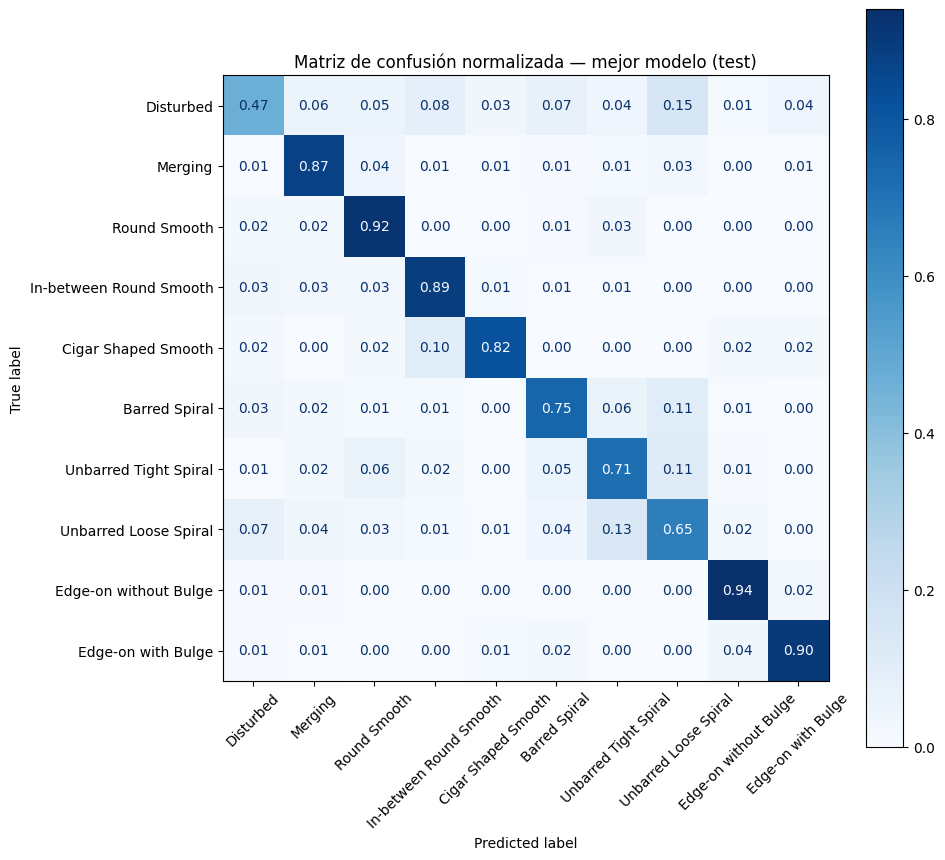

In [14]:
matriz_confusion(y_true, y_pred, NOMBRES_CLASES,
                 ruta="../reports/figures/matriz_confusion.png",
                 titulo="Matriz de confusión normalizada — mejor modelo (test)")

## 7. Conclusiones

- El transfer learning **con fine-tuning** gana claramente a entrenar solo la cabeza o a la baseline.
- ResNet50 adaptada supera a EfficientNetB0 con nuestro protocolo (F1 ~0,78 vs ~0,57).
- Los fallos coinciden con lo que ya intuíamos en el EDA: espirales y smooth se confunden.
- Los pesos de clase ayudan con la clase minoritaria (*Cigar Shaped*).
